<a href="https://colab.research.google.com/github/123xpw/DL-Learning-Lab/blob/main/colab/pokemon_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install diffusers transformers accelerate safetensors -q

In [2]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

print("VAE:     ", pipe.vae.__class__.__name__)
print("CLIP:    ", pipe.text_encoder.__class__.__name__)
print("UNet:    ", pipe.unet.__class__.__name__)
print("Scheduler:", pipe.scheduler.__class__.__name__)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

VAE:      AutoencoderKL
CLIP:     CLIPTextModel
UNet:     UNet2DConditionModel
Scheduler: PNDMScheduler


  0%|          | 0/30 [00:00<?, ?it/s]

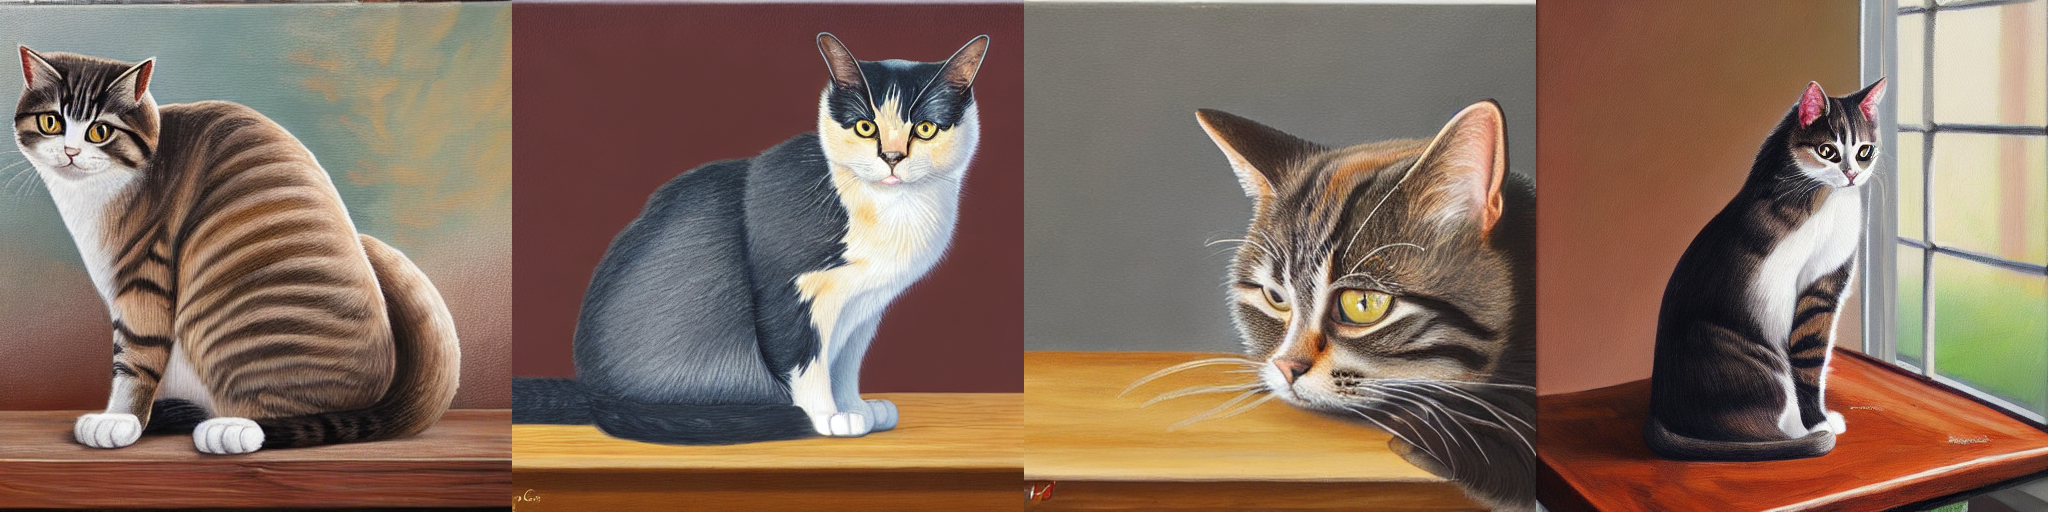

In [4]:
from diffusers.utils import make_image_grid

images = pipe(
    prompt          = "a cat sitting on a wooden table, oil painting style",
    negative_prompt = "blurry, low quality, deformed",
    num_inference_steps = 30,
    guidance_scale      = 7.5,
    num_images_per_prompt = 4,
).images

grid = make_image_grid(images, rows=1, cols=4)
grid.save("sd_output.png")
grid

In [5]:
# 看 VAE 的压缩能力
from PIL import Image
import numpy as np

# 加载刚生成的图
img = Image.open("sd_output.png").crop((0, 0, 512, 512))

# 用 VAE 压缩再还原，看信息损失多少
import torch
from torchvision import transforms

tf  = transforms.ToTensor()
x   = tf(img).unsqueeze(0).to("cuda").half() * 2 - 1   # [1,3,512,512] → [-1,1]

with torch.no_grad():
    latent  = pipe.vae.encode(x).latent_dist.sample()  # 压缩到潜空间
    decoded = pipe.vae.decode(latent).sample            # 还原回像素

print("原始图大小:", x.shape)         # [1, 3, 512, 512]
print("潜变量大小:", latent.shape)    # [1, 4,  64,  64]  ← 压缩了 8×

# 保存还原后的图对比
out = ((decoded.squeeze().permute(1,2,0).cpu().float() + 1) / 2).clamp(0,1)
Image.fromarray((out.numpy()*255).astype("uint8")).save("vae_decoded.png")
print("VAE 还原图已保存")

原始图大小: torch.Size([1, 3, 512, 512])
潜变量大小: torch.Size([1, 4, 64, 64])
VAE 还原图已保存


README.md:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

data/train-00000-of-00001-78e564002aa9c8(…):   0%|          | 0.00/99.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

图片数量: 833
数据格式: dict_keys(['image', 'en_text', 'zh_text'])


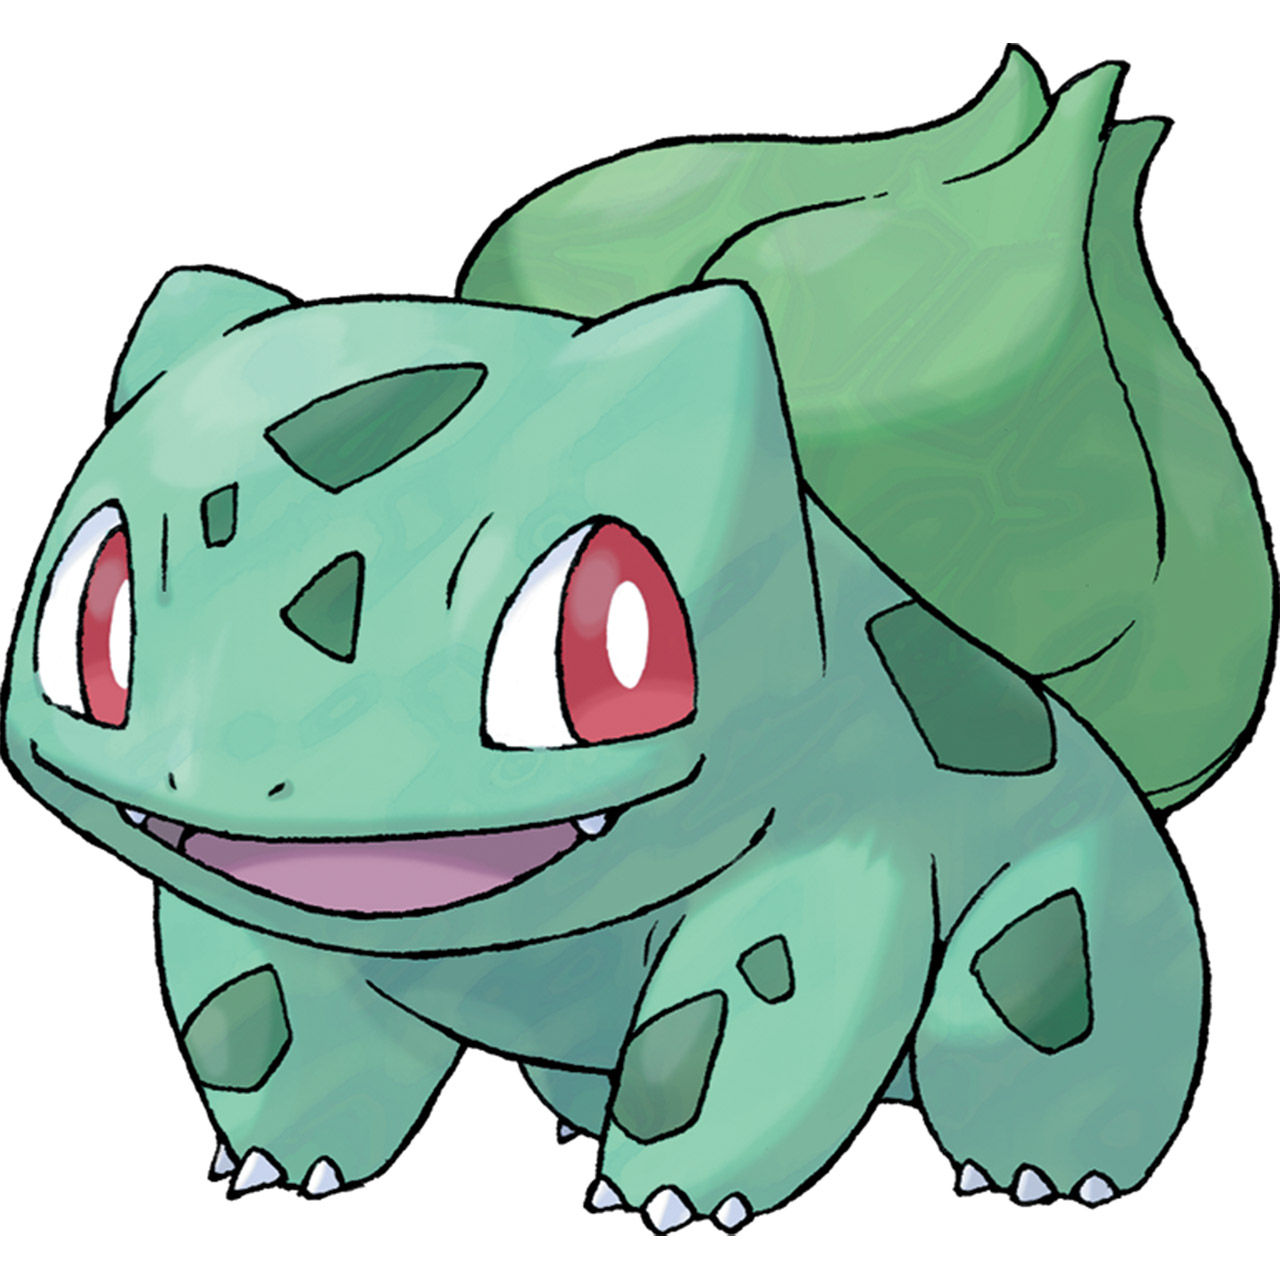

In [7]:
from datasets import load_dataset

ds = load_dataset("svjack/pokemon-blip-captions-en-zh", split="train")
print(f"图片数量: {len(ds)}")
print(f"数据格式: {ds[0].keys()}")
ds[0]["image"]

图片数量: 833
字段: dict_keys(['image', 'en_text', 'zh_text'])
图片大小: a drawing of a green pokemon with red eyes


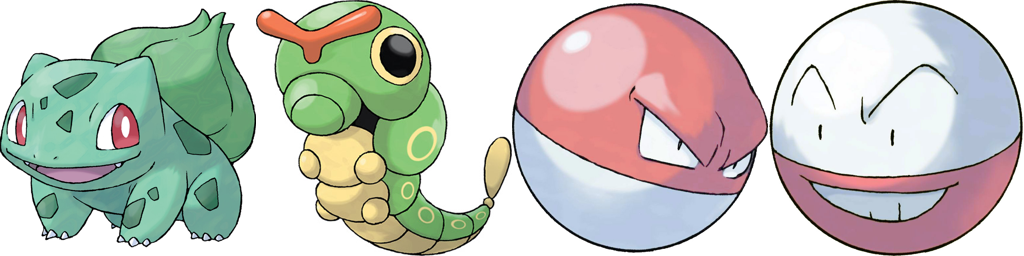

In [8]:
# 查看数据集基本信息
print(f"图片数量: {len(ds)}")
print(f"字段: {ds[0].keys()}")
print(f"图片大小: {ds[0]['en_text']}")

# 显示前4张图
from diffusers.utils import make_image_grid
imgs = [ds[i]["image"].resize((256, 256)) for i in range(4)]
make_image_grid(imgs, rows=1, cols=4)

In [9]:
!pip install peft -q

In [15]:
import torch
import torch.nn as nn

class LoRALinear(nn.Module):
    """用两个小矩阵 A、B 近似权重变化，只训练这两个"""
    def __init__(self, original, rank=4, alpha=4):
        super().__init__()
        self.original = original
        self.original.requires_grad_(False)   # 冻结原始权重
        dev, dtype = original.weight.device, original.weight.dtype
        # A 初始化为小随机数，B 初始化为全零（保证初始 LoRA 输出为零）
        self.lora_A = nn.Parameter(torch.randn(rank, original.in_features, device=dev, dtype=dtype) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(original.out_features, rank, device=dev, dtype=dtype))
        self.scale  = alpha / rank

    def forward(self, x):
        # 原始输出 + LoRA 增量（x @ A^T @ B^T）
        return self.original(x) + (x @ self.lora_A.T @ self.lora_B.T) * self.scale


def inject_lora(unet, targets=("to_k", "to_q", "to_v"), rank=4):
    injected = []
    for name, module in list(unet.named_modules()):
        if not (isinstance(module, nn.Linear) and name.split(".")[-1] in targets):
            continue
        parts  = name.split(".")
        parent = unet
        for p in parts[:-1]:
            parent = parent[int(p)] if p.isdigit() else getattr(parent, p)
        lora = LoRALinear(module, rank=rank)
        setattr(parent, parts[-1], lora)
        injected.append(lora)
    return injected


pipe.unet.requires_grad_(False)
lora_layers = inject_lora(pipe.unet, rank=4)
lora_params = [p for L in lora_layers for p in (L.lora_A, L.lora_B)]

print(f"LoRA 注入层:  {len(lora_layers)} 个")
print(f"训练参数:  {sum(p.numel() for p in lora_params):,}")
print(f"总参数:    {sum(p.numel() for p in pipe.unet.parameters()):,}")

LoRA 注入层:  96 个
训练参数:  597,504
总参数:    860,118,468


In [17]:
from diffusers import UNet2DConditionModel

pipe.unet = UNet2DConditionModel.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="unet",
    torch_dtype=torch.float16
).to("cuda")
pipe.unet.requires_grad_(False)

class LoRALinear(nn.Module):
    def __init__(self, original, rank=4, alpha=4):
        super().__init__()
        self.original = original
        self.original.requires_grad_(False)
        dev = original.weight.device
        # float32 确保数值稳定，不会溢出
        self.lora_A = nn.Parameter(torch.randn(rank, original.in_features, device=dev) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(original.out_features, rank, device=dev))
        self.scale  = alpha / rank

    def forward(self, x):
        # 用 float32 算 LoRA 增量，再转回原始 dtype 相加
        delta = (x.float() @ self.lora_A.T @ self.lora_B.T) * self.scale
        return self.original(x) + delta.to(x.dtype)

lora_layers = inject_lora(pipe.unet, rank=4)
lora_params = [p for L in lora_layers for p in (L.lora_A, L.lora_B)]
print(f"注入: {len(lora_layers)} 层 | 训练参数: {sum(p.numel() for p in lora_params):,}")

注入: 96 层 | 训练参数: 597,504


In [18]:
optimizer = torch.optim.AdamW(lora_params, lr=1e-4)
pipe.unet.train()

for epoch in range(1, 4):
    total_loss = 0
    for batch in loader:
        pixel_values = batch["pixel_values"].to("cuda", dtype=torch.float16)
        input_ids    = batch["input_ids"].to("cuda")

        with torch.no_grad():
            latents  = pipe.vae.encode(pixel_values).latent_dist.sample()
            latents  = latents * pipe.vae.config.scaling_factor
            text_emb = pipe.text_encoder(input_ids)[0]

        noise         = torch.randn_like(latents)
        t             = torch.randint(0, 1000, (latents.shape[0],), device="cuda").long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, t)

        noise_pred = pipe.unet(noisy_latents, t, encoder_hidden_states=text_emb).sample
        loss       = F.mse_loss(noise_pred.float(), noise.float())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_params, 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}/3 | loss: {total_loss/len(loader):.4f}")

torch.save(lora_params, "pokemon_lora.pt")
print("保存完成: pokemon_lora.pt")

Epoch 1/3 | loss: 0.0537
Epoch 2/3 | loss: 0.0584
Epoch 3/3 | loss: 0.0605
保存完成: pokemon_lora.pt


  0%|          | 0/30 [00:00<?, ?it/s]

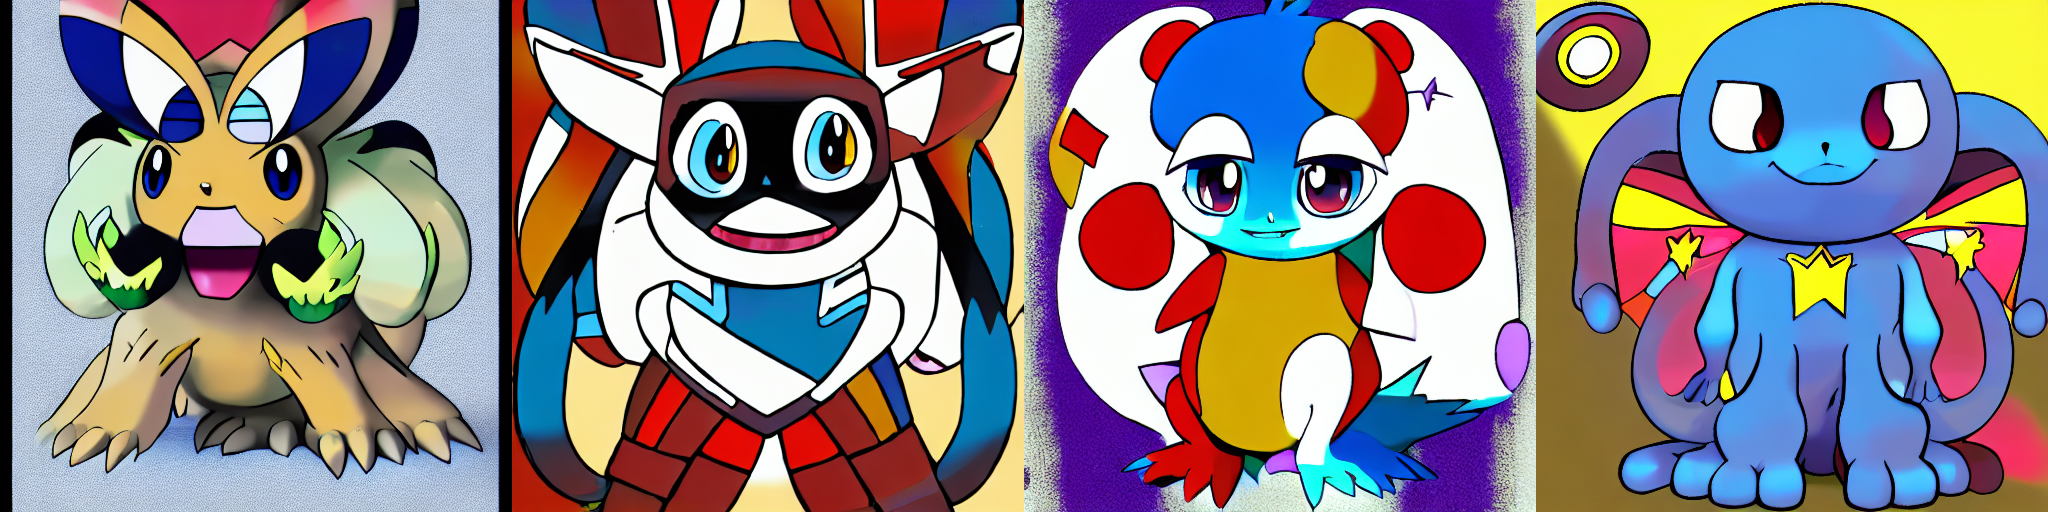

In [19]:
pipe.unet.eval()

# 用 LoRA 生成
images_lora = pipe(
    prompt          = "a cute pokemon creature with blue eyes, cartoon style",
    negative_prompt = "blurry, low quality, realistic, photo",
    num_inference_steps = 30,
    guidance_scale      = 7.5,
    num_images_per_prompt = 4,
).images

from diffusers.utils import make_image_grid
grid = make_image_grid(images_lora, rows=1, cols=4)
grid.save("pokemon_lora_output.png")
grid